<h1>Predobrada dermatoloških slika</h1>

<p>Prateći notebook uz seminarski rad, u kome se demonstriraju tehnike o kojima je bilo reči u radu: kako kvalitet slike (šum, zamućenje, slab kontrast, artefakti) utiče na klasifikaciju, i koliko predobrada i augmentacija mogu da poprave (ili pokvare) rezultat. </p>
<p>Koriste se tri datoteke iz skupa:</p>
<ul>
<li><code>HAM10000_metadata.csv</code> — 10.015 redova sa oznakama (dx), načinom verifikacije (dx_type) i metapodacima (uzrast, pol, lokalizacija). Osnova za EDA.</li>
<li><code>hmnist_28_28_RGB.csv</code> — iste lezije kao 28×28 RGB slike (2352 piksela + label). Na njima radimo predobradu i klasifikaciju.</li>
<li><code>ISIC_0024306.jpg</code> — jedna slika u punoj rezoluciji (600×450), za demonstraciju artefakata (dlake, segmentacija) gde je 28×28 premalo.</li>
</ul>


<h1>1 Podešavanje i biblioteke </h1>

In [10]:
import time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from scipy.ndimage import gaussian_filter

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report)

In [11]:
RS = 42
np.random.seed(RS)
plt.rcParams["figure.figsize"] = (10, 6)

DATA = os.environ.get("HAM_DATA", "./Data")
META_CSV  = f"{DATA}/HAM10000_metadata.csv"
PIXEL_CSV = f"{DATA}/hmnist_28_28_RGB.csv"
SAMPLE_IMG = f"{DATA}/ISIC_0024306.jpg"

In [12]:
LABELS = ["akiec", "bcc", "bkl", "df", "nv", "vasc", "mel"]
FULL = {
    "akiec": "Aktinicna keratoza / Bowen (akiec)",
    "bcc":   "Bazocelularni karcinom (bcc)",
    "bkl":   "Benigna keratoza (bkl)",
    "df":    "Dermatofibrom (df)",
    "nv":    "Melanocitni nevus (nv)",
    "vasc":  "Vaskularne lezije (vasc)",
    "mel":   "Melanom (mel)",
}

<h1>2 Učitavanje i EDA metapodataka</h1>
<p>Pre slika, obradjuje se tabela metapodataka. Ona otkriva najvažnije osobine skupa koje će kasnije diktirati predobradu</p>

In [13]:
meta = pd.read_csv(META_CSV)
print("oblik:", meta.shape)
meta.head()

oblik: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [14]:
meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


<h2>2.1 Raspodela klasa</h2>


In [16]:
counts = meta.dx.value_counts()
perc = (counts / counts.sum() * 100).round(1)
dist = pd.DataFrame({"broj": counts, "udeo_%": perc, "pun_naziv": [FULL[d] for d in counts.index]})
dist

,broj,udeo_%,pun_naziv
dx,,,
nv,6705,66.9,Melanocitni nevus (nv)
mel,1113,11.1,Melanom (mel)
bkl,1099,11.0,Benigna keratoza (bkl)
bcc,514,5.1,Bazocelularni karcinom (bcc)
akiec,327,3.3,Aktinicna keratoza / Bowen (akiec)
vasc,142,1.4,Vaskularne lezije (vasc)
df,115,1.1,Dermatofibrom (df)


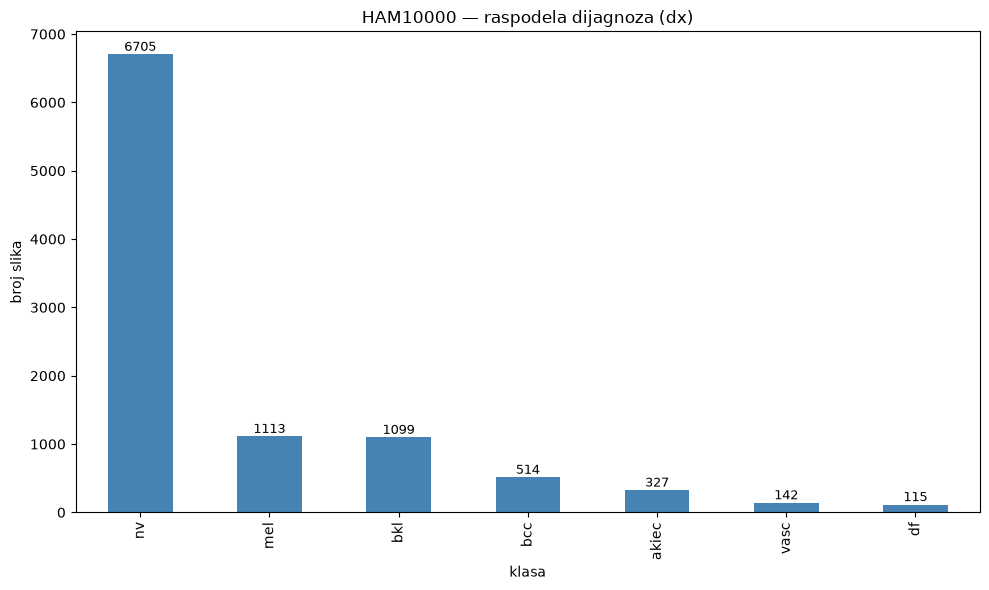

In [17]:
ax = counts.plot(kind="bar", color="steelblue")
ax.set_title("HAM10000 — raspodela dijagnoza (dx)"); ax.set_xlabel("klasa"); ax.set_ylabel("broj slika")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

<p>Klasa <b>nv (melanocitni nevus)</b> ima 6705 slika (preko 66% skupa) dok najređa klasa <b>df (dermatofibrom)</b> ima svega 115 (oko 1.1%). Odnos najčešće i najređe klase je oko <b>58:1</b>. Ovo je ključni problem: model koji uvek predviđa <code>nv</code> postiže oko 67% tačnosti ne naučivši ništa. Zato tačnost (accuracy) ovde vara, a pravu sliku daju <b>balanced accuracy</b> i <b>macro-F1</b>, koje jednako tretiraju sve klase. Klinički je najopasnije prevideti <b>mel (melanom)</b>, koji je takođe manjinska klasa.</p>

<h2>2.2 Način verifikacije dijagnoze (dx_type)</h2>
<p>HAM10000 dijagnoze nisu sve jednako pouzdane, zavise od načina potvrde.</p>

In [18]:
vt = meta.dx_type.value_counts()
vtp = (vt/vt.sum()*100).round(1)
pd.DataFrame({"broj": vt, "udeo_%": vtp})

,broj,udeo_%
dx_type,,
histo,5340,53.3
follow_up,3704,37.0
consensus,902,9.0
confocal,69,0.7


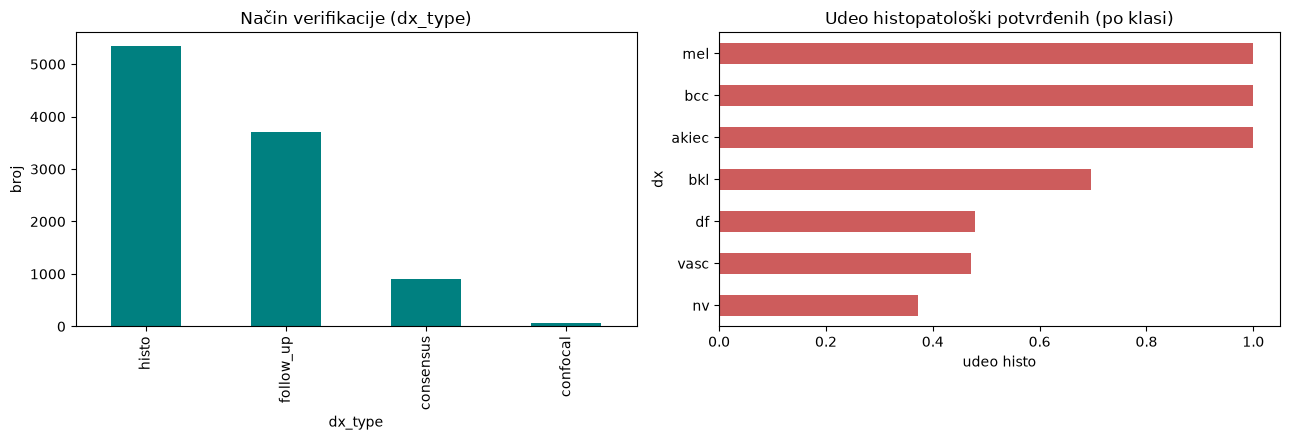

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
meta.dx_type.value_counts().plot(kind="bar", ax=ax[0], color="teal")
ax[0].set_title("Način verifikacije (dx_type)"); ax[0].set_ylabel("broj")
# udeo histo verifikacije po klasi
ct = pd.crosstab(meta.dx, meta.dx_type, normalize="index")["histo"].sort_values()
ct.plot(kind="barh", ax=ax[1], color="indianred")
ax[1].set_title("Udeo histopatološki potvrđenih (po klasi)"); ax[1].set_xlabel("udeo histo")
plt.tight_layout(); plt.show()

<p>Oko 53% dijagnoza je <b>histopatološki</b> potvrđeno (najpouzdanije), a značajan deo počiva na <b>follow-up</b> praćenju ili stručnom <b>consensus</b>-u. Maligne klase (mel, bcc, akiec) gotovo su uvek histološki potvrđene, dok je kod benignih nevusa (nv) veliki deo potvrđen samo praćenjem, što je razumno klinički, ali znači da oznake nisu uniformnog kvaliteta.</p>

<h2>2.3 Uzrast, pol i lokalizacija</h2>

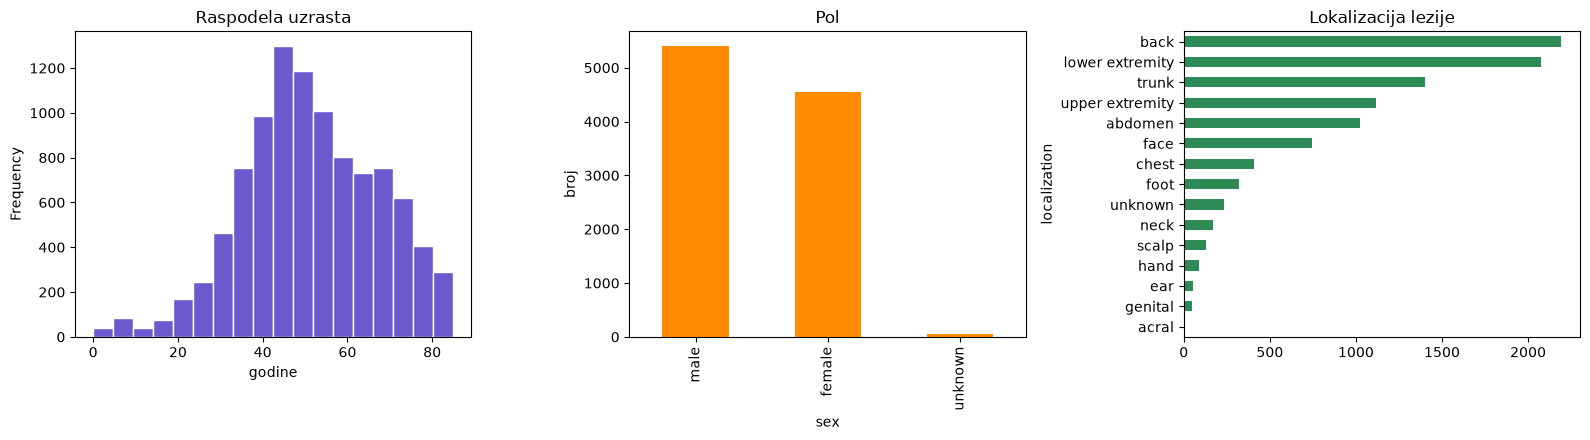

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
meta.age.dropna().plot(kind="hist", bins=18, ax=ax[0], color="slateblue", edgecolor="white")
ax[0].set_title("Raspodela uzrasta"); ax[0].set_xlabel("godine")
meta.sex.value_counts().plot(kind="bar", ax=ax[1], color="darkorange")
ax[1].set_title("Pol"); ax[1].set_ylabel("broj")
meta.localization.value_counts().plot(kind="barh", ax=ax[2], color="seagreen")
ax[2].set_title("Lokalizacija lezije"); ax[2].invert_yaxis()
plt.tight_layout(); plt.show()

In [21]:
print("uzrast: prosek = %.1f, opseg = %.0f-%.0f, nedostaje = %d" % (
      meta.age.mean(), meta.age.min(), meta.age.max(), meta.age.isna().sum()))
print("pol 'unknown':", int((meta.sex == 'unknown').sum()))

uzrast: prosek = 51.9, opseg = 0-85, nedostaje = 57
pol 'unknown': 57


<h2>2.4 Duplikati lezija (lesion_id)</h2>
<p>Važan, lako previđen detalj: ista lezija ume da ima više slika. To znači da slučajna podela train/test može da <b>iscuri</b> (data leakage).</p>

In [23]:
print("redova (slika):", len(meta))
print("jedinstvenih lezija:", meta.lesion_id.nunique())
per = meta.groupby("lesion_id").size().value_counts().sort_index()
print("\nslika po leziji:")
print(per)

redova (slika): 10015
jedinstvenih lezija: 7470

slika po leziji:
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64


<p>Od 10.015 slika ima samo <b>7470 jedinstvenih lezija</b>, gotovo 25% su dodatne slike postojećih lezija.

<h1>3 Učitavanje slika (pixel CSV)</h1>
<p><code>hmnist_28_28_RGB.csv</code> ima po jednoj liniji za svaku leziju, 2352 vrednosti piksela (28×28×3) i kolonu <code>label</code>.</p>

In [24]:
t = time.time()
NPY_X, NPY_Y = f"{DATA}/X_all.npy", f"{DATA}/y_all.npy"
if os.path.exists(NPY_X):                       # brzo: keširani niz
    X_all = np.load(NPY_X); y_all = np.load(NPY_Y)
else:                                           # prvi put: čita CSV pa kešira
    px = pd.read_csv(PIXEL_CSV)
    X_all = px.drop(columns=["label"]).values.astype(np.uint8).reshape(-1, 28, 28, 3)
    y_all = px["label"].values
    np.save(NPY_X, X_all); np.save(NPY_Y, y_all)
print("učitano:", X_all.shape, "za %.1f s" % (time.time()-t))
print("X opseg:", X_all.min(), "-", X_all.max())
print("y:", dict(zip(LABELS, np.bincount(y_all))))

učitano: (10015, 28, 28, 3) za 1.7 s
X opseg: 0 - 255
y: {'akiec': np.int64(327), 'bcc': np.int64(514), 'bkl': np.int64(1099), 'df': np.int64(115), 'nv': np.int64(6705), 'vasc': np.int64(142), 'mel': np.int64(1113)}


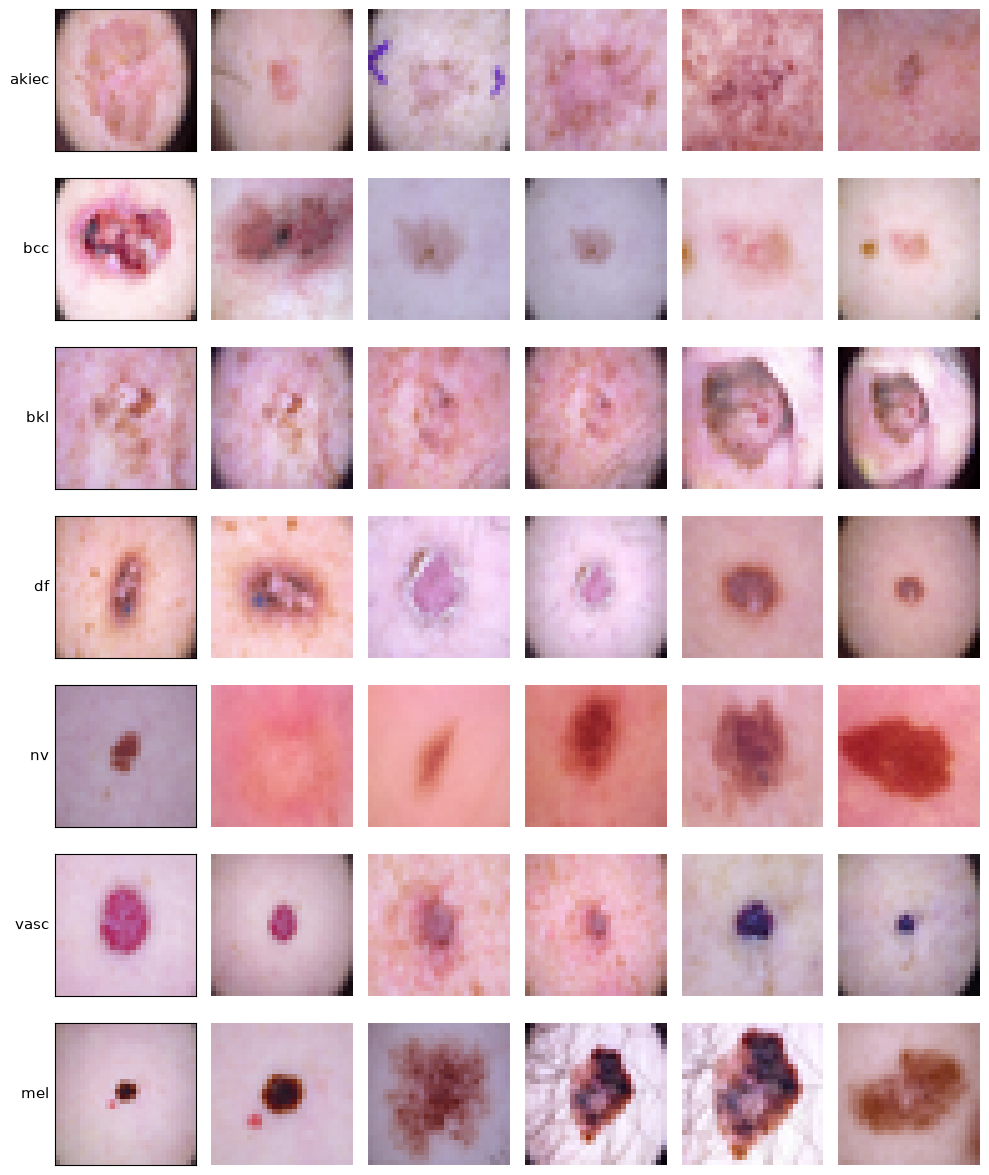

In [26]:
fig, axes = plt.subplots(7, 6, figsize=(10, 12))
for r, lab in enumerate(range(7)):
    idx = np.where(y_all == lab)[0][:6]
    for c, i in enumerate(idx):
        axes[r, c].imshow(X_all[i]); axes[r, c].axis("off")
    axes[r, 0].set_ylabel(LABELS[lab], rotation=0, ha="right", va="center", fontsize=11)
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
plt.tight_layout()
plt.show()